In [18]:
import os
import pickle
import pandas as pd
import glob
from tqdm import tqdm, trange
import joblib

# math imports
import numpy as np
import scipy
import sklearn
from sklearn.model_selection import train_test_split

import warnings
import matplotlib
from matplotlib import pyplot

import copy
from functools import reduce

from dataclasses import dataclass

import sys
sys.path.append('../../')
from src.data_class import matrix_class
from utils.util import reduce_class

In [3]:
def filter_questionnaires(pickle_list, identity_col, threshold):
    response_list = []
    dataname_list = []
    description_list = []
    df_list = []
    for file in pickle_list:
        questionnaire = pickle.load(open(file, 'rb'))
        df_list.append(questionnaire['data'])
        response_list.append([r[0] for r in questionnaire['response_info']])
        dataname_list.append(file.replace('.pickle', '').split('/')[-1])
        description_list.append(questionnaire['data_info'])
    dfmerge = reduce(lambda left,right: pd.merge(left, right, how='outer', left_on=identity_col, right_on=identity_col), df_list)
    
    include_list = []
    for (idx, q) in enumerate(dataname_list):
        Mvalue = dfmerge[ response_list[idx] ].values
        include = np.sum(pd.isnull(Mvalue))/(Mvalue.shape[0]*Mvalue.shape[1]) < 1.0 - threshold
        include_list.append([q, Mvalue.shape[1], include])
            
    filter_list = pd.DataFrame(include_list, columns=['Questionnaire', 'dimension', '>20% available'])
    filter_list = filter_list.sort_values(by=['>20% available', 'Questionnaire']).reset_index(drop=True)
    display(filter_list)
    return [q[0] for q in include_list if q[2] == True]

In [5]:
pickle_list = glob.glob('./processed/pickle/*.pickle')
pickle_list = [ p for p in pickle_list if 'Barratt' not in p]
pickle_list = [ p for p in pickle_list if '_pos.' not in p]
pickle_list.sort()
identity_col = ['EID', 'Age', 'Sex']
threshold = 0.2

dataname_list  = filter_questionnaires(pickle_list, identity_col, threshold)

,Questionnaire,dimension,>20% available
0,ASR,126,False
1,CAARS,26,False
2,CDI2_P,17,False
3,CDI2_SR,10,False
4,ARI_P,7,True
5,ARI_S,7,True
6,ASSQ,27,True
7,C3SR,39,True
8,CBCL,119,True
9,ESWAN,65,True


### Detect duplicate subject

In [8]:
df_list = []
sdf_list = [] # scaled df list
norm_df_list = []
response_list = []
minmax_list = []

max_age = 0
min_age = 100

for dataname in tqdm(dataname_list):
    data = pickle.load(open('./processed/pickle/{}.pickle'.format(dataname), 'rb'))

    df = data['data']
    response_info = data['response_info']
    itemlist = [r[0] for r in response_info]
    for i in itemlist: minmax_list.append([data['min_response'], data['max_response']])
    if data['max_age'] > max_age: max_age = data['max_age']
    if data['min_age'] < min_age: min_age = data['min_age']

    # Drop duplicate rows
    df = df.drop_duplicates(subset=['Age', 'EID'] + itemlist)
    df_list.append(df)
    response_list.append(response_info)
    
minmax_list = np.array(minmax_list)
df_merge = reduce(lambda left,right: pd.merge(left,right, how='outer'), df_list)

unique_EID, unique_idx = np.unique(df_merge['EID'].values, return_index=True)
duplicates = df_merge.iloc[list(set(np.arange(df_merge.shape[0])) - set(unique_idx))]['EID'].values
print('The following subjects have duplicated responses: ')
print(duplicates)
# display(df_merge.loc[df_merge['EID'] == duplicates[0]])

100%|██████████| 21/21 [00:00<00:00, 56.31it/s]


The following subjects have duplicated responses: 
['NDARPL406KX4']


### drop duplicated subjects

In [9]:
df_merge = df_merge.drop([3568])
df_merge.reset_index(inplace=True)
unique_EID, unique_idx = np.unique(df_merge['EID'].values, return_index=True)
duplicates = df_merge.iloc[list(set(np.arange(df_merge.shape[0])) - set(unique_idx))]['EID'].values
assert len(duplicates) == 0

print('Unique subjects : {}'.format(df_merge.shape[0]))
print('Age range : {:.2f} -- {:.2f}'.format(min_age, max_age))

Unique subjects : 3572
Age range : 5.00 -- 21.90


### merge questionnaires

In [10]:
response_merge_list = [r for sublist in response_list for r in sublist]
itemlist = [r[0] for r in response_merge_list]

M_raw = df_merge[itemlist].values
nan_mask = 1.0 - np.isnan(M_raw)

M = copy.deepcopy(M_raw)
for i in range(M.shape[1]):
    lb, ub = minmax_list[i][0], minmax_list[i][1]
    M[:,i][np.isnan(M[:,i])] = lb
    M[:,i] = (M[:,i] - lb)/(ub - lb)

assert np.sum(np.isnan(M)) == 0
assert np.max(M) <= 1.0
assert np.min(M) >= 0.0

confound_raw = df_merge[['Age', 'Sex']].values
confound = copy.deepcopy(confound_raw)
confound[:,0] = (confound[:,0] - min_age)/(max_age - min_age)
assert np.sum(np.isnan(confound)) == 0

subjlist = list(df_merge['EID'].values)

matrix_merge = matrix_class(M, M_raw,
                            confound, confound_raw,
                            nan_mask,
                            None, None, None, # row_idx, col_idx, mask
                            'Merged questionnaires',
                            subjlist,
                            response_merge_list,
                            None, None, # W, Q
                            None, None, # C, Qc
                            None, None) # Z, aZ

os.makedirs('../../output/full-HBN_split', exist_ok=True)

with open('../../output/full-HBN_split/merge.pickle', 'wb') as handle:
    pickle.dump(matrix_merge, handle, protocol=4)
    
np.savez('../../output/full-HBN_split/merge.npz', M=M, nan_mask=nan_mask, confound=confound)

### update matrix class for each questionnaire on row_idx, col_idx and mask

In [13]:
matrix_merge = pickle.load(open('../../output/full-HBN_split/merge.pickle', 'rb'))
itemlist_merge = matrix_merge.itemlist
subjlist_merge = matrix_merge.subjlist

matrix_list = []
for dataname in tqdm(dataname_list):
    matrixpath = './processed/dataclass/{}.pickle'.format(dataname)
    matrix = pickle.load(open(matrixpath, 'rb'))
    
    dataname = matrix.dataname
    itemlist = matrix.itemlist
    subjlist = matrix.subjlist
    
    row_idx = [subjlist_merge.index(subj) for subj in subjlist]
    col_idx = np.array([itemlist_merge.index(item) for item in itemlist])
    
    matrix.row_idx = row_idx
    matrix.col_idx = col_idx
    
    assert matrix.M.shape[0] == len(row_idx)
    assert matrix.M.shape[1] == len(col_idx)
    
    mask = np.zeros_like(matrix_merge.M)
    index = np.ix_(row_idx, col_idx)
    
    mask[index] = np.ones((len(row_idx), len(col_idx)))
    
    matrix.mask = mask
    matrix_list.append(matrix)
    
    os.makedirs('../../output/full-HBN_split/dataclass', exist_ok=True)
    with open(os.path.join('../../output/full-HBN_split/dataclass', '{}.pickle'.format(dataname)), 'wb') as handle:
        pickle.dump(matrix, handle, protocol=4)

100%|██████████| 21/21 [00:05<00:00,  3.57it/s]


### visualize full-HBN questionnaires response

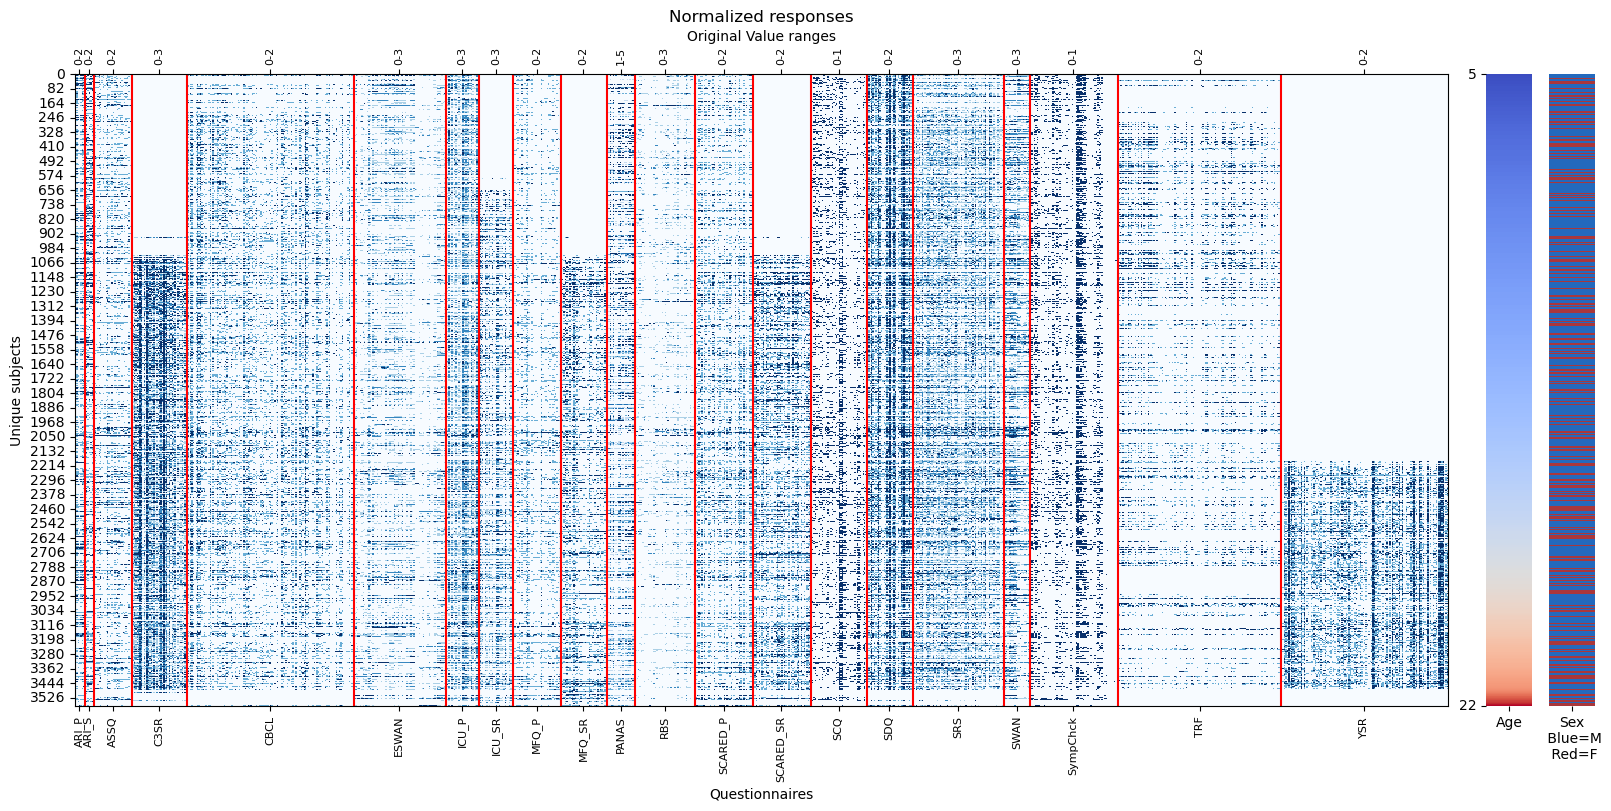

In [25]:
import seaborn as sns

fig = pyplot.figure(figsize=(16, 8), constrained_layout=True)
spec = fig.add_gridspec(ncols=3, nrows=1, width_ratios=[30, 1, 1])

ax = fig.add_subplot(spec[0,0])

age_sort = np.argsort(matrix_merge.confound[:,0])

nquestion_list = [m.M.shape[1] for m in matrix_list]
xtickslocation = np.cumsum(np.asarray([0]+nquestion_list[:-1])) + np.asarray(nquestion_list)//2
sns.heatmap(matrix_merge.M[age_sort], ax=ax, cmap="Blues", cbar=False)
ax.set_xticks(xtickslocation)
ax.set_xticklabels(dataname_list, rotation=90, fontsize=8)

range_list = []
for dataname in dataname_list:
    datapath = './processed/pickle/{}.pickle'.format(dataname)
    data = pickle.load(open(datapath, 'rb'))
    range_list.append('{}-{}'.format(int(data['min_response']), int(data['max_response'])))
    
for y in np.cumsum(nquestion_list[:-1]):
    ax.axvline(x=y, c='r')
ax.set_xlim([0, matrix_merge.M.shape[1]])
ax.set_title('Normalized responses')
ax.set_xlabel('Questionnaires')
ax.set_ylabel('Unique subjects')
ax_a = ax.twiny()
ax_a.set_xlim(ax.get_xlim())
ax_a.set_xticks(xtickslocation)
ax_a.set_xticklabels(range_list, rotation=90, fontsize=8)
ax_a.set_xlabel('Original Value ranges')

ax2 = fig.add_subplot(spec[0,1])

sns.heatmap(matrix_merge.confound[:,0][age_sort][:,np.newaxis], ax=ax2, cmap="coolwarm", cbar=False)
ax2.set_xticks([0.5])
ax2.set_xticklabels(['Age'])
ax2.set_yticks([0, matrix_merge.M.shape[0]])
ax2.set_yticklabels([int(data['min_age']), int(np.round(data['max_age']))])

ax3 = fig.add_subplot(spec[0,2])
sns.heatmap(matrix_merge.confound[:,1][age_sort][:,np.newaxis], ax=ax3, cmap="vlag", cbar=False)
ax3.set_xticks([0.5])
ax3.set_xticklabels(['Sex\n Blue=M\n Red=F'])
ax3.set_yticks([])

pyplot.savefig('../../output/figure/full-HBN.png', dpi=300)  
pyplot.show()

### split dataset conditoned on population distribution and data availability

In [16]:
matrix_merge = pickle.load(open('../../output/full-HBN_split/merge.pickle', 'rb'))

from sklearn.model_selection import train_test_split
gender_split = matrix_merge.confound[:,1]


age_split = np.zeros(matrix_merge.M.shape[0])
ages = matrix_merge.confound[:,0]
n_age_split = 10
for i in range(n_age_split):
    age_group = np.where(np.logical_and(ages >= i/n_age_split, ages < (i+1)/n_age_split))[0]
    age_split[age_group] += i

NaN_split = np.zeros(matrix_merge.nan_mask.shape[0])
for res in response_list:
    sub_col = [r[0] for r in res]
    NaN_group = np.where(df_merge[sub_col].isnull().all(1) == 1)[0]
    NaN_split[NaN_group] += 1
    
classes = age_split
classes[gender_split == 1] *= 2


In [21]:
nsubj = matrix_merge.M.shape[0]
split_idx = 0
while split_idx < 30:
    try: 
        _Xtrain, _Xvalid, _ytrain, _yvalid = train_test_split(np.arange(nsubj), classes, stratify=classes, test_size=0.3)
        _Xvalid, _Xtest, _yvalid, _ytest = train_test_split(_Xvalid, _yvalid, stratify=_yvalid, test_size=0.5)

        subject_train = []
        subject_valid = []
        subject_test = []

        for group in [_Xtrain, _Xvalid, _Xtest]:
            Xtrain, Xvalid, ytrain, yvalid = train_test_split(group, NaN_split[group], stratify=NaN_split[group], test_size=0.3)
            try:
                Xvalid, Xtest, yvalid, ytest = train_test_split(Xvalid, yvalid, stratify=yvalid, test_size=0.5)
            except:
                new_split = reduce_class(yvalid, 2)
                Xvalid, Xtest, yvalid, ytest = train_test_split(Xvalid, new_split, stratify=new_split, test_size=0.5)

            subject_train.append(Xtrain)
            subject_valid.append(Xvalid)
            subject_test.append(Xtest)
        
        subject_train = np.concatenate(subject_train)
        subject_valid = np.concatenate(subject_valid)
        subject_test = np.concatenate(subject_test)
        
        ttt_size = len(list(set( list(subject_train) + list(subject_valid) + list(subject_test) )))
        assert nsubj == ttt_size
        
        os.makedirs('../../output/full-HBN_split/repeat_{}'.format(split_idx+1), exist_ok=True)
        np.savez('../../output/full-HBN_split/repeat_{}/split.npz'.format(split_idx+1),
                 train=subject_train, valid=subject_valid, test=subject_test)
        
        split_idx +=1
        
    except:
        pass


### visualize split data 

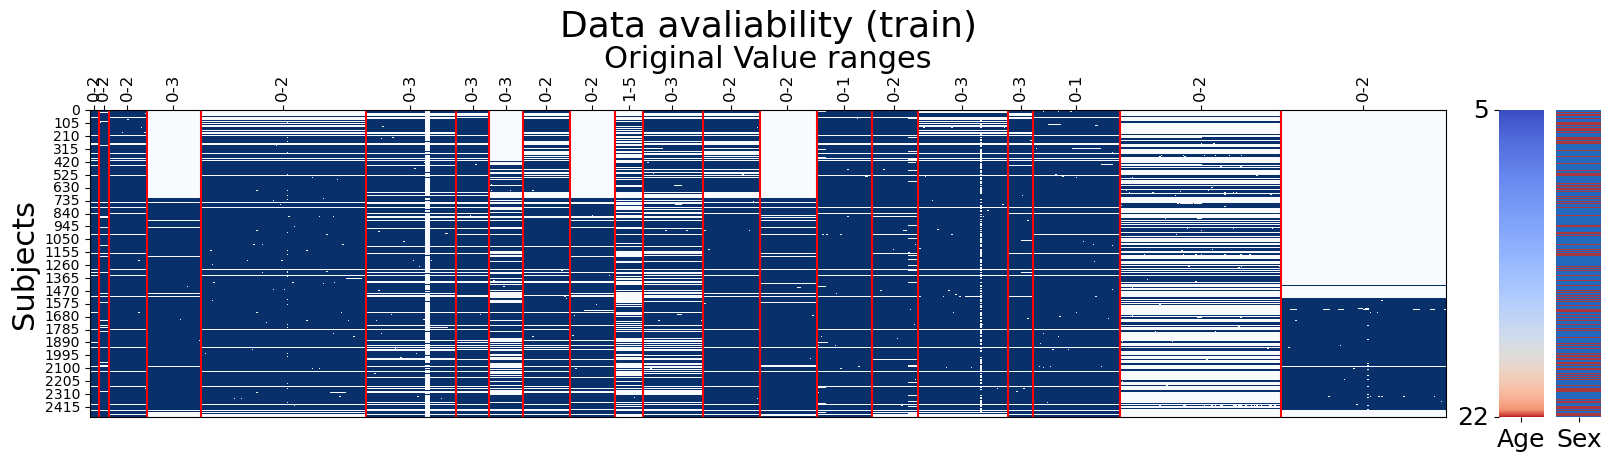

In [26]:
fulldata = np.load('../../output/full-HBN_split/repeat_{}/split.npz'.format(1))
subject_train = fulldata['train']

fig = pyplot.figure(figsize=(16, 4.5), constrained_layout=True)
spec = fig.add_gridspec(ncols=3, nrows=1, width_ratios=[30, 1, 1])

_split_type = subject_train
_age_sort = np.argsort(matrix_merge.confound[:,0][_split_type])

ax = fig.add_subplot(spec[0,0])

nquestion_list = [m.M.shape[1] for m in matrix_list]
xtickslocation = np.cumsum(np.asarray([0]+nquestion_list[:-1])) + np.asarray(nquestion_list)//2
sns.heatmap(matrix_merge.nan_mask[_split_type][_age_sort], ax=ax, cmap="Blues", cbar=False)
ax.set_xticks(xtickslocation)
ax.set_xticklabels(dataname_list, rotation=90, fontsize=12)

range_list = []
for dataname in dataname_list:
    datapath = './processed/pickle/{}.pickle'.format(dataname)
    data = pickle.load(open(datapath, 'rb'))
    range_list.append('{}-{}'.format(int(data['min_response']), int(data['max_response'])))

for y in np.cumsum(nquestion_list[:-1]):
    ax.axvline(x=y, c='r')
ax.set_xlim([0, matrix_merge.M[_split_type].shape[1]])
ax.set_title('Data avaliability (train)', fontsize=26)
ax.set_ylabel('Subjects', fontsize=22)
ax.set_xticks([])
ax_a = ax.twiny()
ax_a.set_xlim(ax.get_xlim())
ax_a.set_xticks(xtickslocation)
ax_a.set_xticklabels(range_list, rotation=90, fontsize=12)
ax_a.set_xlabel('Original Value ranges', fontsize=22)

split_min_age = np.min(matrix_merge.confound[:,0][_split_type][_age_sort])
split_max_age = np.max(matrix_merge.confound[:,0][_split_type][_age_sort])
split_size = len(_age_sort)

ax2 = fig.add_subplot(spec[0,1])
sns.heatmap(matrix_merge.confound[:,0][_split_type][_age_sort][:,np.newaxis], ax=ax2, cmap="coolwarm", cbar=False)
ax2.set_xticks([0.5])
ax2.set_xticklabels(['Age'], fontsize=18)
ax2.set_yticks([0, split_size])
ax2.set_yticklabels([5, int(np.round(split_max_age*data['max_age']))], fontsize=18)

ax3 = fig.add_subplot(spec[0,2])
sns.heatmap(matrix_merge.confound[:,1][_split_type][_age_sort][:,np.newaxis], ax=ax3, cmap="vlag", cbar=False)
ax3.set_xticks([0.5])
ax3.set_xticklabels(['Sex'], fontsize=18)
ax3.set_yticks([])

pyplot.savefig('../../output/figure/merge_train.png', dpi=300)  
pyplot.show()

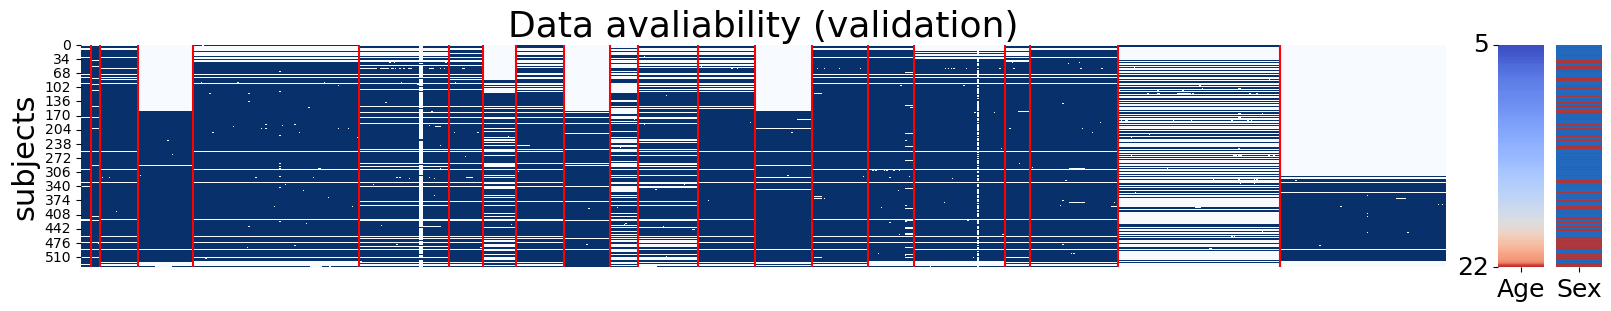

In [28]:
subject_valid = fulldata['valid']

fig = pyplot.figure(figsize=(16, 3), constrained_layout=True)
spec = fig.add_gridspec(ncols=3, nrows=1, width_ratios=[30, 1, 1])

_split_type = subject_valid
_age_sort = np.argsort(matrix_merge.confound[:,0][_split_type])

ax = fig.add_subplot(spec[0,0])

nquestion_list = [m.M.shape[1] for m in matrix_list]
xtickslocation = np.cumsum(np.asarray([0]+nquestion_list[:-1])) + np.asarray(nquestion_list)//2
sns.heatmap(matrix_merge.nan_mask[_split_type][_age_sort], ax=ax, cmap="Blues", cbar=False)
ax.set_xticks(xtickslocation)
ax.set_xticklabels(dataname_list, rotation=90, fontsize=12)

range_list = []
for dataname in dataname_list:
    datapath = './processed/pickle/{}.pickle'.format(dataname)
    data = pickle.load(open(datapath, 'rb'))
    range_list.append('{}-{}'.format(int(data['min_response']), int(data['max_response'])))

for y in np.cumsum(nquestion_list[:-1]):
    ax.axvline(x=y, c='r')
ax.set_xlim([0, matrix_merge.M[_split_type].shape[1]])
ax.set_title('Data avaliability (validation)', fontsize=26)
ax.set_xticks([])
ax.set_ylabel('subjects', fontsize=22)

split_min_age = np.min(matrix_merge.confound[:,0][_split_type][_age_sort])
split_max_age = np.max(matrix_merge.confound[:,0][_split_type][_age_sort])
split_size = len(_age_sort)

ax2 = fig.add_subplot(spec[0,1])
sns.heatmap(matrix_merge.confound[:,0][_split_type][_age_sort][:,np.newaxis], ax=ax2, cmap="coolwarm", cbar=False)
ax2.set_xticks([0.5])
ax2.set_xticklabels(['Age'], fontsize=18)
ax2.set_yticks([0, split_size])
ax2.set_yticklabels([5, int(np.round(split_max_age*data['max_age']))], fontsize=18)

ax3 = fig.add_subplot(spec[0,2])
sns.heatmap(matrix_merge.confound[:,1][_split_type][_age_sort][:,np.newaxis], ax=ax3, cmap="vlag", cbar=False)
ax3.set_xticks([0.5])
ax3.set_xticklabels(['Sex'], fontsize=18)
ax3.set_yticks([])

pyplot.savefig('../../output/figure/merge_valid.png', dpi=300)   
pyplot.show()

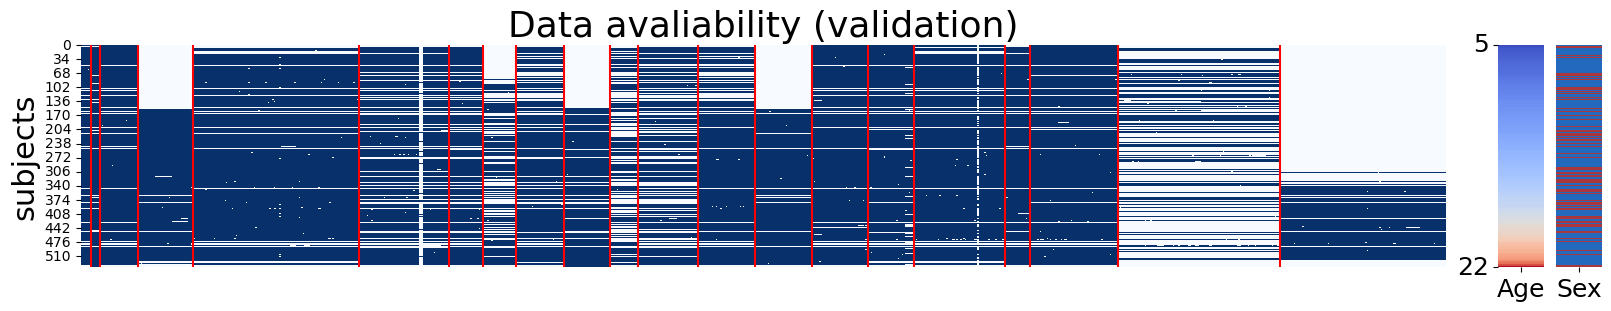

In [29]:
subject_valid = fulldata['test']

fig = pyplot.figure(figsize=(16, 3), constrained_layout=True)
spec = fig.add_gridspec(ncols=3, nrows=1, width_ratios=[30, 1, 1])

_split_type = subject_valid
_age_sort = np.argsort(matrix_merge.confound[:,0][_split_type])

ax = fig.add_subplot(spec[0,0])

nquestion_list = [m.M.shape[1] for m in matrix_list]
xtickslocation = np.cumsum(np.asarray([0]+nquestion_list[:-1])) + np.asarray(nquestion_list)//2
sns.heatmap(matrix_merge.nan_mask[_split_type][_age_sort], ax=ax, cmap="Blues", cbar=False)
ax.set_xticks(xtickslocation)
ax.set_xticklabels(dataname_list, rotation=90, fontsize=12)

range_list = []
for dataname in dataname_list:
    datapath = './processed/pickle/{}.pickle'.format(dataname)
    data = pickle.load(open(datapath, 'rb'))
    range_list.append('{}-{}'.format(int(data['min_response']), int(data['max_response'])))

for y in np.cumsum(nquestion_list[:-1]):
    ax.axvline(x=y, c='r')
ax.set_xlim([0, matrix_merge.M[_split_type].shape[1]])
ax.set_title('Data avaliability (validation)', fontsize=26)
ax.set_xticks([])
ax.set_ylabel('subjects', fontsize=22)

split_min_age = np.min(matrix_merge.confound[:,0][_split_type][_age_sort])
split_max_age = np.max(matrix_merge.confound[:,0][_split_type][_age_sort])
split_size = len(_age_sort)

ax2 = fig.add_subplot(spec[0,1])
sns.heatmap(matrix_merge.confound[:,0][_split_type][_age_sort][:,np.newaxis], ax=ax2, cmap="coolwarm", cbar=False)
ax2.set_xticks([0.5])
ax2.set_xticklabels(['Age'], fontsize=18)
ax2.set_yticks([0, split_size])
ax2.set_yticklabels([5, int(np.round(split_max_age*data['max_age']))], fontsize=18)

ax3 = fig.add_subplot(spec[0,2])
sns.heatmap(matrix_merge.confound[:,1][_split_type][_age_sort][:,np.newaxis], ax=ax3, cmap="vlag", cbar=False)
ax3.set_xticks([0.5])
ax3.set_xticklabels(['Sex'], fontsize=18)
ax3.set_yticks([])

pyplot.savefig('../../output/figure/merge_test.png', dpi=300)   
pyplot.show()